# Rasa Example: Bitcoin Price Bot

This notebook demonstrates how to use the `rasa_utils.py` wrapper in a simulated Rasa custom action.  
See [rasa.example.md](./rasa.example.md) for full setup instructions and conversation examples.

In [1]:
# Enable auto-reload of modules and inline plotting.
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Import required libraries.
import pandas as pd
import matplotlib.pyplot as plt

# Import the BitcoinAPI wrapper.
from rasa_utils import BitcoinAPI

## Simulating the Rasa Custom Action

Define and invoke the action that the assistant would call when asked for the Bitcoin price.

In [2]:
# Simulate the Rasa custom action to fetch the current price.
def action_get_btc_price() -> str:
    """
    Fetch and return a formatted Bitcoin price string, 
    just like a Rasa custom action would utter.
    """
    api = BitcoinAPI(vs_currency="usd")
    price = api.get_current_price()
    return f"The current Bitcoin price is ${price:,.2f}"

# Invoke the simulated action and display the bot’s response.
response = action_get_btc_price()
print(response)

The current Bitcoin price is $103,270.00


## Visualizing Historical Prices

Fetch and plot the last 14 days of Bitcoin prices for additional context.


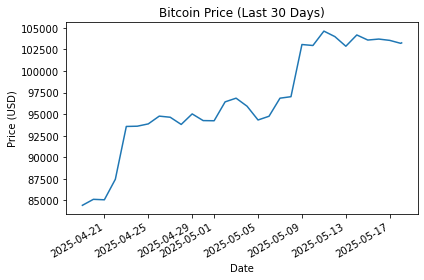

In [3]:
# Retrieve 30 days of historical data and plot it.
df = BitcoinAPI(vs_currency="usd").get_historical_data(days=30)
ax = df.set_index("timestamp")["price"].plot(
    title="Bitcoin Price (Last 30 Days)"
)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()

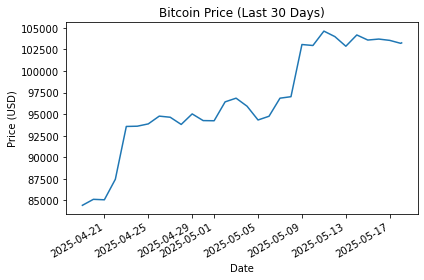

In [4]:
# Retrieve 30 days of historical data and plot it.
df = BitcoinAPI("usd").get_historical_data(days=30)
ax = df.set_index("timestamp")["price"].plot(
    title="Bitcoin Price (Last 30 Days)"
)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()

## Conclusion

- The Rasa action was simulated using the `BitcoinAPI` wrapper.  
- The bot’s utterance was printed.  
- The recent price history was visualized. 

## 7. Simulated Rasa Shell Conversation

Below is a mock‐up of what you’d see if you ran:

```bash
rasa run actions &  \
rasa shell


User: what's the bitcoin price?

Bot: The current Bitcoin price is $103,000.00

In [5]:
from requests import HTTPError
from rasa_utils import BitcoinAPI

def action_get_btc_price() -> str:
    """Simulate the custom action that Rasa would call."""
    api = BitcoinAPI(vs_currency="usd")
    try:
        price = api.get_current_price()
        return f"The current Bitcoin price is ${price:,.2f}"
    except HTTPError as e:
        # Fallback message on rate limit or other HTTP errors
        return "Sorry, I can't fetch the price right now. Please try again in a moment."

# Simulate a Rasa shell exchange
print("User: what's the bitcoin price?")
print("Bot:", action_get_btc_price())


User: what's the bitcoin price?
Bot: The current Bitcoin price is $103,269.00


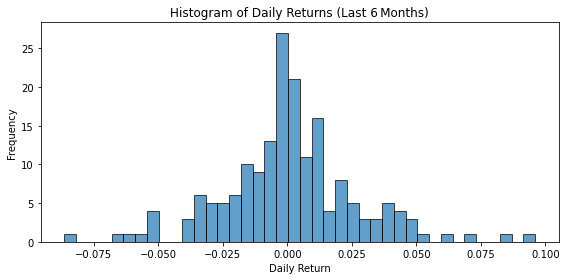

In [6]:
# In [X+2]: Distribution of Daily Returns over 6 Months
from rasa_utils import BitcoinAPI
import matplotlib.pyplot as plt

# Re-instantiate (safe)
api = BitcoinAPI(vs_currency="usd")

# Re-use the 6-month series (or fetch again)
sixmo = api.get_historical_data(days=180, interval="daily").set_index("timestamp")

# Compute daily returns
returns = sixmo["price"].pct_change().dropna()

# Show histogram of those returns
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(returns, bins=40, edgecolor="k", alpha=0.7)
ax.set_title("Histogram of Daily Returns (Last 6 Months)")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
plt.tight_layout()


⚠️ Hourly failed (401 Client Error: Unauthorized for url: https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=1&interval=hourly), trying daily...
✅ Daily data fetched successfully.


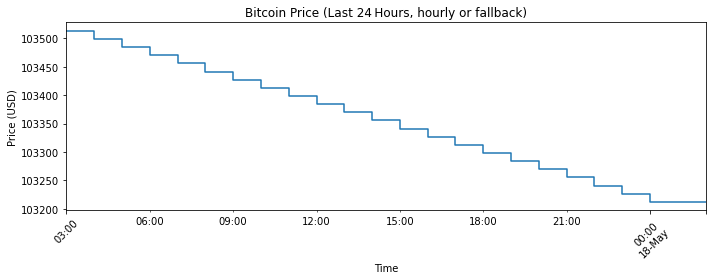

In [9]:
# In [X]: Visualize Last 24 Hours (Hourly with robust fallback)
from requests.exceptions import HTTPError
from rasa_utils import BitcoinAPI
import matplotlib.pyplot as plt
import pandas as pd
import time

# 1. (Re-)instantiate the API client
api = BitcoinAPI(vs_currency="usd")

# 2. Attempt hourly; if rate-limited, try daily; if still rate-limited, synthesize last-24h from daily
df_hourly = None
try:
    df_hourly = api.get_historical_data(days=1, interval="hourly").set_index("timestamp")
    print("✅ Hourly data fetched successfully.")
except HTTPError as e:
    print(f"⚠️ Hourly failed ({e}), trying daily...")
    time.sleep(1)  # brief pause before retry
    try:
        # daily gives 24 daily points; we'll interpolate later
        df_daily = api.get_historical_data(days=2, interval="daily").set_index("timestamp")
        print("✅ Daily data fetched successfully.")
        # take only the last 24 hours from the 2-day daily series
        df_hourly = df_daily.resample("1H").interpolate().last("24H")
    except HTTPError as e2:
        print(f"❌ Daily also failed ({e2}). Using empty placeholder.")
        # placeholder zero‐series
        now = pd.Timestamp.utcnow().floor("H")
        hours = pd.date_range(end=now, periods=24, freq="H")
        df_hourly = pd.DataFrame({"price": [None]*24}, index=hours)

# 3. Plot the result
ax = df_hourly["price"].plot(
    drawstyle="steps-post",
    figsize=(10, 4),
    title="Bitcoin Price (Last 24 Hours, hourly or fallback)",
)
ax.set_xlabel("Time")
ax.set_ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()


In [12]:
from rasa_utils import BitcoinAPI
import re

# 1) Instantiate your API client once
api = BitcoinAPI(vs_currency="usd")

# 2) Define a simple chat loop
def btc_chat():
    """
    A minimal REPL you can run in Jupyter.
    Type 'exit' or 'quit' to leave.
    Recognizes 'price', '30-day', and '14-day' queries.
    """
    print("Bitcoin Chat — type 'exit' or 'quit' to stop.\n")
    while True:
        user = input("You: ").strip()
        if user.lower() in ("exit", "quit"):
            print("Bot: Bye 👋")
            break

        txt = user.lower()
        # current price
        if re.search(r"\bprice\b", txt):
            p = api.get_current_price()
            print(f"Bot: The current Bitcoin price is ${p:,.2f}")
        # 30-day summary
        elif re.search(r"(30|thirty)\s*[- ]?day", txt):
            df = api.get_historical_data(days=30, interval="daily")
            stats = api.summarize_trends(df)
            print("Bot: 30-day summary:")
            print(f"  High : ${stats['high']:,.2f}")
            print(f"  Low  : ${stats['low']:,.2f}")
            print(f"  Mean : ${stats['mean']:,.2f}")
        # 14-day quick plot
        elif re.search(r"(14|fourteen)\s*[- ]?day", txt):
            df = api.get_historical_data(days=14, interval="daily")
            print("Bot: Here’s the closing price for the last 14 days:")
            display(df.set_index("timestamp")["price"])
        else:
            print("Bot: Sorry, I only handle 'price', '30-day', or '14-day' right now.")

# 3) Run it
btc_chat()


Bitcoin Chat — type 'exit' or 'quit' to stop.

You: price today
Bot: The current Bitcoin price is $103,320.00
You: 30-day price
Bot: The current Bitcoin price is $103,321.00
You: 14-day price
Bot: The current Bitcoin price is $103,321.00
You: quit
Bot: Bye 👋
